# Skill Evolution: Structural Change or Monthly Noise?

## Decision Question

Did the skill composition of India's data job market undergo a meaningful structural shift during 2023, or were most observed changes simply short-term fluctuations?

Raw skill counts can be misleading because hiring activity varies from month to month. To isolate changes in skill demand from changes in posting volume, this analysis measures **skill prevalence**: the percentage of job postings in a given period that mention a particular skill.

Two complementary measures are used to separate trend from noise:

* **Half-year change** identifies directional movement by comparing skill prevalence in the first and second halves of 2023.
* **Monthly volatility** measures how stable that movement is by quantifying month-to-month variation.

Together, these metrics distinguish sustained shifts in employer demand from temporary fluctuations, allowing the analysis to assess whether 2023 reflected gradual evolution or a material restructuring of the data job market.

In [7]:
import ast

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from datasets import load_dataset

In [8]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])


def parse_skills(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    if isinstance(value, list):
        return value
    return []


df["job_skills"] = df["job_skills"].apply(parse_skills)

india_jobs = df[df["job_country"] == "India"].copy()

print(f"Total dataset postings: {len(df):,}")
print(f"India postings: {len(india_jobs):,}")
print(f"Analysis year: {india_jobs['job_posted_date'].dt.year.mode()[0]}")

assert not india_jobs.empty
assert india_jobs["job_country"].eq("India").all()
assert india_jobs["job_posted_date"].dt.year.nunique() == 1

Total dataset postings: 785,741
India postings: 51,088
Analysis year: 2023


## Data Preparation

The analysis is restricted to India-based job postings published during 2023. Skills listed in each posting are parsed into structured skill arrays and expanded into a skill-level dataset.

To account for fluctuations in hiring activity throughout the year, skill demand is measured using monthly prevalence rather than raw mention counts. Monthly prevalence represents the percentage of job postings in a given month that reference a particular skill.

For each month-skill combination, prevalence is calculated as:

Skill Prevalence = Postings Mentioning Skill ÷ Total Monthly Postings

This normalization ensures that changes in posting volume do not distort comparisons across months. The resulting matrix contains one prevalence estimate for every month-skill combination and serves as the foundation for both the half-year change and monthly volatility analyses.

In [9]:
india_jobs["month"] = (
    india_jobs["job_posted_date"]
    .dt.to_period("M")
)

monthly_totals = (
    india_jobs
    .groupby("month")
    .size()
)

monthly_skill_counts = (
    india_jobs
    .explode("job_skills")
    .groupby(["month", "job_skills"])
    .size()
    .unstack(fill_value=0)
)

monthly_prevalence = (
    monthly_skill_counts
    .div(monthly_totals, axis=0)
)

assert monthly_prevalence.notna().all().all()
assert monthly_prevalence.ge(0).all().all()
assert monthly_prevalence.le(1).all().all()

In [10]:
# Notebook-wide visualization settings

sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "figure.titlesize": 16,
    "figure.dpi": 110
})

## Stable Core vs Emerging Skills

The first test of structural change compares skill prevalence between the first half (H1) and second half (H2) of 2023. Changes are measured in percentage points rather than percent growth to reflect differences in market share directly.

To reduce noise from niche technologies, the analysis is limited to skills with at least 3% prevalence in either half of the year. This threshold focuses attention on skills with meaningful representation in the job market while excluding movements driven by low-prevalence tools.

A positive change indicates that a skill appeared in a larger share of postings during H2 than H1, while a negative change indicates declining prevalence. If the market experienced a structural shift, the largest skills would be expected to show substantial directional movement over the course of the year.

Rank,Skill,First Half,Second Half,Change (pp)
1,pytorch,4.7%,6.2%,+1.5 pp
2,tensorflow,6.3%,7.7%,+1.4 pp
3,gcp,9.3%,10.6%,+1.3 pp
4,scikit-learn,3.1%,4.1%,+1.0 pp
5,power bi,10.8%,11.6%,+0.8 pp
6,r,14.9%,15.7%,+0.8 pp
7,hadoop,16.4%,14.2%,-2.2 pp
8,mongodb,8.8%,6.5%,-2.3 pp
9,nosql,11.0%,8.7%,-2.3 pp
10,java,16.0%,13.6%,-2.4 pp


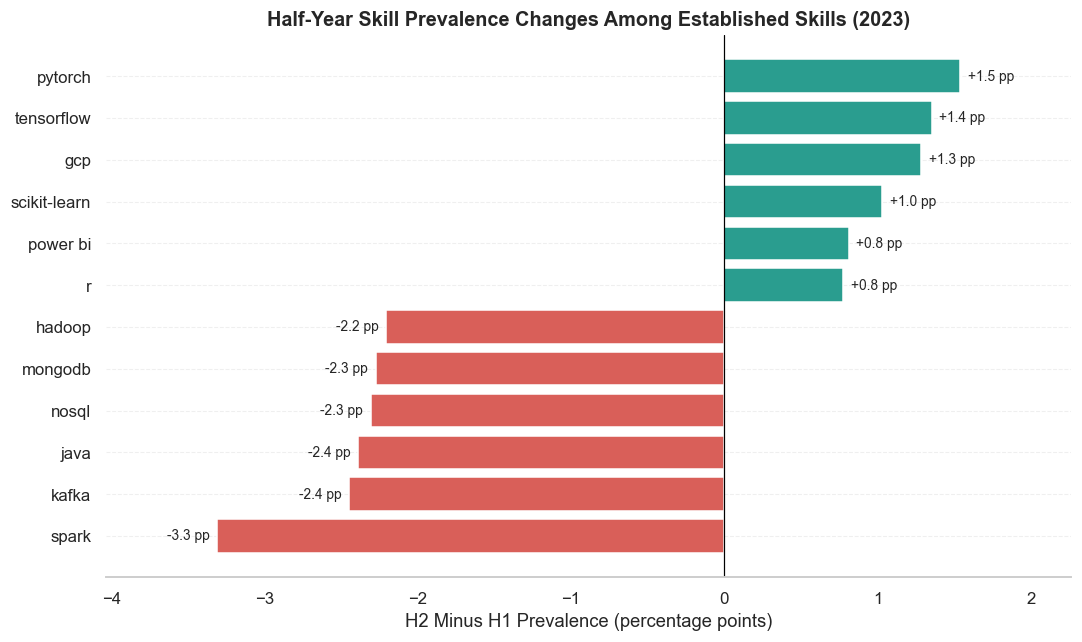

In [11]:
india_jobs["half"] = india_jobs["job_posted_date"].dt.month.map(
    lambda month: "H1" if month <= 6 else "H2"
)

half_totals = india_jobs.groupby("half").size()

half_prevalence = (
    india_jobs.explode("job_skills")
    .groupby(["half", "job_skills"])
    .size()
    .unstack(fill_value=0)
    .div(half_totals, axis=0)
)

change = pd.DataFrame(
    {
        "H1": half_prevalence.loc["H1"],
        "H2": half_prevalence.loc["H2"],
    }
)

change["change_pp"] = (change["H2"] - change["H1"]) * 100

change = change[
    change[["H1", "H2"]].max(axis=1) >= 0.03
]

change_to_plot = (
    pd.concat(
        [
            change.nlargest(6, "change_pp"),
            change.nsmallest(6, "change_pp"),
        ]
    )
    .drop_duplicates()
    .sort_values("change_pp")
)

display_table = (
    change_to_plot
    .sort_values("change_pp", ascending=False)
    .reset_index()
    .rename(
        columns={
            "job_skills": "Skill",
            "H1": "First Half",
            "H2": "Second Half",
            "change_pp": "Change (pp)",
        }
    )
)

display_table.insert(
    0,
    "Rank",
    range(1, len(display_table) + 1)
)

display(
    display_table.style.format(
        {
            "First Half": "{:.1%}",
            "Second Half": "{:.1%}",
            "Change (pp)": "{:+.1f} pp",
        }
    ).hide(axis="index")
)

colors = [
    "#2a9d8f" if value > 0 else "#d95f59"
    for value in change_to_plot["change_pp"]
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    change_to_plot.index,
    change_to_plot["change_pp"],
    color=colors,
)

for bar in bars:
    width = bar.get_width()

    if width >= 0:
        ax.text(
            width + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{width:+.1f} pp",
            va="center",
            fontsize=9,
        )
    else:
        ax.text(
            width - 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{width:+.1f} pp",
            ha="right",
            va="center",
            fontsize=9,
        )

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set(
    title="Half-Year Skill Prevalence Changes Among Established Skills (2023)",
    xlabel="H2 Minus H1 Prevalence (percentage points)",
    ylabel="",
)

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.3,
)

ax.grid(False, axis="x")

sns.despine(
    top=True,
    right=True,
    left=True,
    bottom=False,
)

ax.set_axisbelow(True)

ax.margins(x=0.15)

plt.tight_layout()
plt.show()

The half-year comparison shows evidence of movement within the skill landscape, but not evidence of a major structural shift. The largest gains were recorded by PyTorch (+1.5 pp), TensorFlow (+1.4 pp), and GCP (+1.3 pp). On the downside, Spark (-3.3 pp) experienced the largest decline, followed by Kafka, Java, NoSQL, and MongoDB.

Despite these changes, the magnitude of movement remained limited to single-digit percentage points, and the most prevalent skills continued to occupy leading positions throughout the year. The results suggest gradual adjustment in employer preferences rather than a fundamental reordering of the market's skill composition during 2023.

## Volatility Check

Half-year change measures directional movement, but it does not reveal whether that movement occurred steadily or through short-lived fluctuations. To evaluate the reliability of observed changes, this section measures monthly volatility using the standard deviation of monthly skill prevalence.

Higher volatility indicates that a skill's prevalence varied substantially from month to month, while lower volatility suggests a more stable demand pattern. A skill that exhibits high volatility but little net half-year change may appear to be trending even though its movement reflects temporary noise.

By comparing half-year change with monthly volatility, the analysis distinguishes sustained shifts in employer demand from short-term fluctuations that are unlikely to represent structural market change.

Rank,Skill,Average Prevalence,Monthly Volatility,Half-Year Change (pp)
1,spark,25.8%,2.2%,-3.3 pp
2,python,58.5%,1.9%,-0.5 pp
3,sql,58.1%,1.6%,-2.0 pp
4,kafka,10.5%,1.6%,-2.4 pp
5,hadoop,15.3%,1.5%,-2.2 pp
6,nosql,9.8%,1.4%,-2.3 pp
7,mongodb,7.6%,1.4%,-2.3 pp
8,java,14.8%,1.3%,-2.4 pp
9,aws,26.9%,1.3%,-0.5 pp
10,gcp,10.0%,1.1%,+1.3 pp


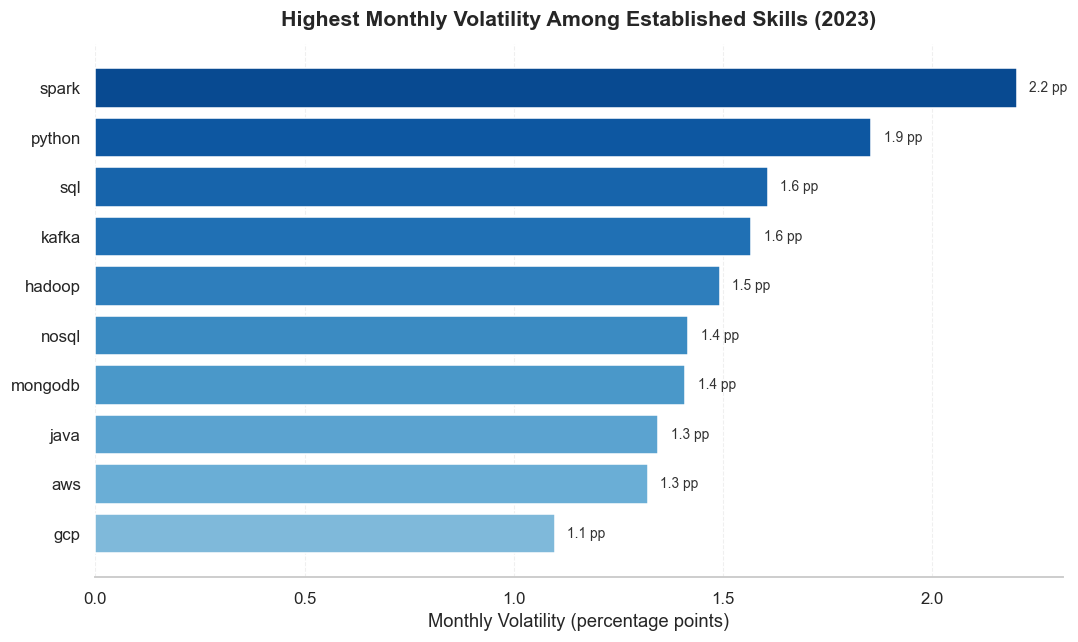

In [12]:
skill_profile = pd.DataFrame(
    {
        "average_prevalence": monthly_prevalence.mean(),
        "monthly_volatility": monthly_prevalence.std(),
        "half_year_change_pp": change["change_pp"],
    }
).dropna()

display_table = (
    skill_profile[skill_profile["average_prevalence"] >= 0.05]
    .sort_values("monthly_volatility", ascending=False)
    .reset_index()
    .rename(
        columns={
            "job_skills": "Skill",
            "average_prevalence": "Average Prevalence",
            "monthly_volatility": "Monthly Volatility",
            "half_year_change_pp": "Half-Year Change (pp)",
        }
    )
)

display_table.insert(
    0,
    "Rank",
    range(1, len(display_table) + 1)
)

display(
    display_table.style.format(
        {
            "Average Prevalence": "{:.1%}",
            "Monthly Volatility": "{:.1%}",
            "Half-Year Change (pp)": "{:+.1f} pp",
        }
    ).hide(axis="index")
)

top_volatility = (
    skill_profile[skill_profile["average_prevalence"] >= 0.05]
    .sort_values("monthly_volatility", ascending=False)
    .head(10)
)

colors = plt.cm.Blues(
    np.linspace(0.90, 0.45, len(top_volatility))
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_volatility.index,
    top_volatility["monthly_volatility"] * 100,
    color=colors,
)

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f} pp",
        va="center",
        fontsize=9,
        color="#333333",
    )

ax.set_title(
    "Highest Monthly Volatility Among Established Skills (2023)",
    fontsize=14,
    pad=12,
)

ax.set_xlabel(
    "Monthly Volatility (percentage points)"
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    top_volatility["monthly_volatility"].max() * 100 * 1.05
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.3,
)

ax.grid(False, axis="y")

sns.despine(
    top=True,
    right=True,
    left=True,
    bottom=False,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

The volatility analysis reveals widespread month-to-month fluctuation across established skills, but limited evidence that these fluctuations translated into lasting changes in market structure. Spark exhibited the highest volatility among established skills, while Python, SQL, Kafka, and Hadoop also experienced noticeable variation throughout the year.

Despite this short-term movement, the most prevalent skills maintained relatively stable positions within the overall skill hierarchy. Core technologies such as AWS, Azure, Databricks, and Power BI combined moderate-to-low volatility with limited half-year change, indicating consistent employer demand rather than rapid shifts in preference.

Taken together, the volatility and half-year analyses point to the same conclusion: short-term variation was common during 2023, but the underlying analyst skill landscape remained broadly stable and showed little evidence of a major structural reordering.

## Implications

The analysis provides little evidence that employers fundamentally changed their skill requirements during 2023. Most established technologies maintained similar positions throughout the year despite observable month-to-month fluctuations.

- **Prioritize durable core skills.** Python (58.5% prevalence) and SQL (58.1%) remained the most consistently requested technical skills across the market and continued to form the foundation of data-oriented roles.

- **Cloud and data platforms exhibited stable demand patterns.** AWS, Azure, Databricks, and GCP remained widely represented throughout the year, showing persistence despite modest changes in prevalence.

- **Power BI showed meaningful positive momentum.** Among established tools, Power BI combined meaningful market presence (11.2% average prevalence) with a positive half-year shift (+0.8 pp) and relatively low volatility (0.6 pp).

- **Avoid overinterpreting short-term fluctuations.** Several technologies, including Spark, Python, SQL, Kafka, and Hadoop, experienced noticeable month-to-month variation, but these movements generally did not translate into major changes in the overall skill hierarchy.

Overall, the evidence suggests that employer demand evolved gradually during 2023 rather than undergoing a significant structural reordering.

## Limitations

This analysis is limited to India-based job postings published during a single calendar year (2023). While the methodology can identify short-term changes in skill prevalence, it cannot determine whether those changes represent long-term structural trends.

The analysis also measures employer demand through job posting content rather than actual hiring outcomes. Changes in posting behavior, hiring mix, duplicate listings, or data collection processes may influence measured prevalence independently of genuine labor market demand.

Additionally, half-year comparisons capture directional movement but do not explain the underlying causes of that movement. Changes in technology adoption, employer preferences, economic conditions, or hiring strategies cannot be inferred directly from posting data alone.

A stronger assessment of structural change would require multiple years of comparable data to determine whether observed movements persist beyond a single annual cycle.